# Imports

In [3]:
# ----------------- Load packages ------------------- #
import os
import contextlib
import io
import numpy as np
import pandas as pd
import mne
from scipy.io import loadmat
import warnings
import matplotlib.pyplot as plt
import time
from pathlib import Path
from datetime import datetime
from scipy.stats import spearmanr
import statsmodels.formula.api as smf


from somnopy import *
from somnopy.somno import get_sosp, get_sosp_for_folder
from somnopy.event_detection import SO_detection, SP_detection, detect_swa
from somnopy.metrics import pac,event_lock
from somnopy.utils import set_up_raw
from somnopy.polysomnography import PolySomnoGraphy
from somnopy.YasaFunctions import YasaFunctions
import yasa
from lspopt import spectrogram_lspopt
from IPython.display import Image, display



c:\Users\Beast\anaconda3\envs\somnopy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Params

Run the following cell to visualize the input and output structure of this pipeline's data. For a more detailed description, see the comments at the beginning of the following cell

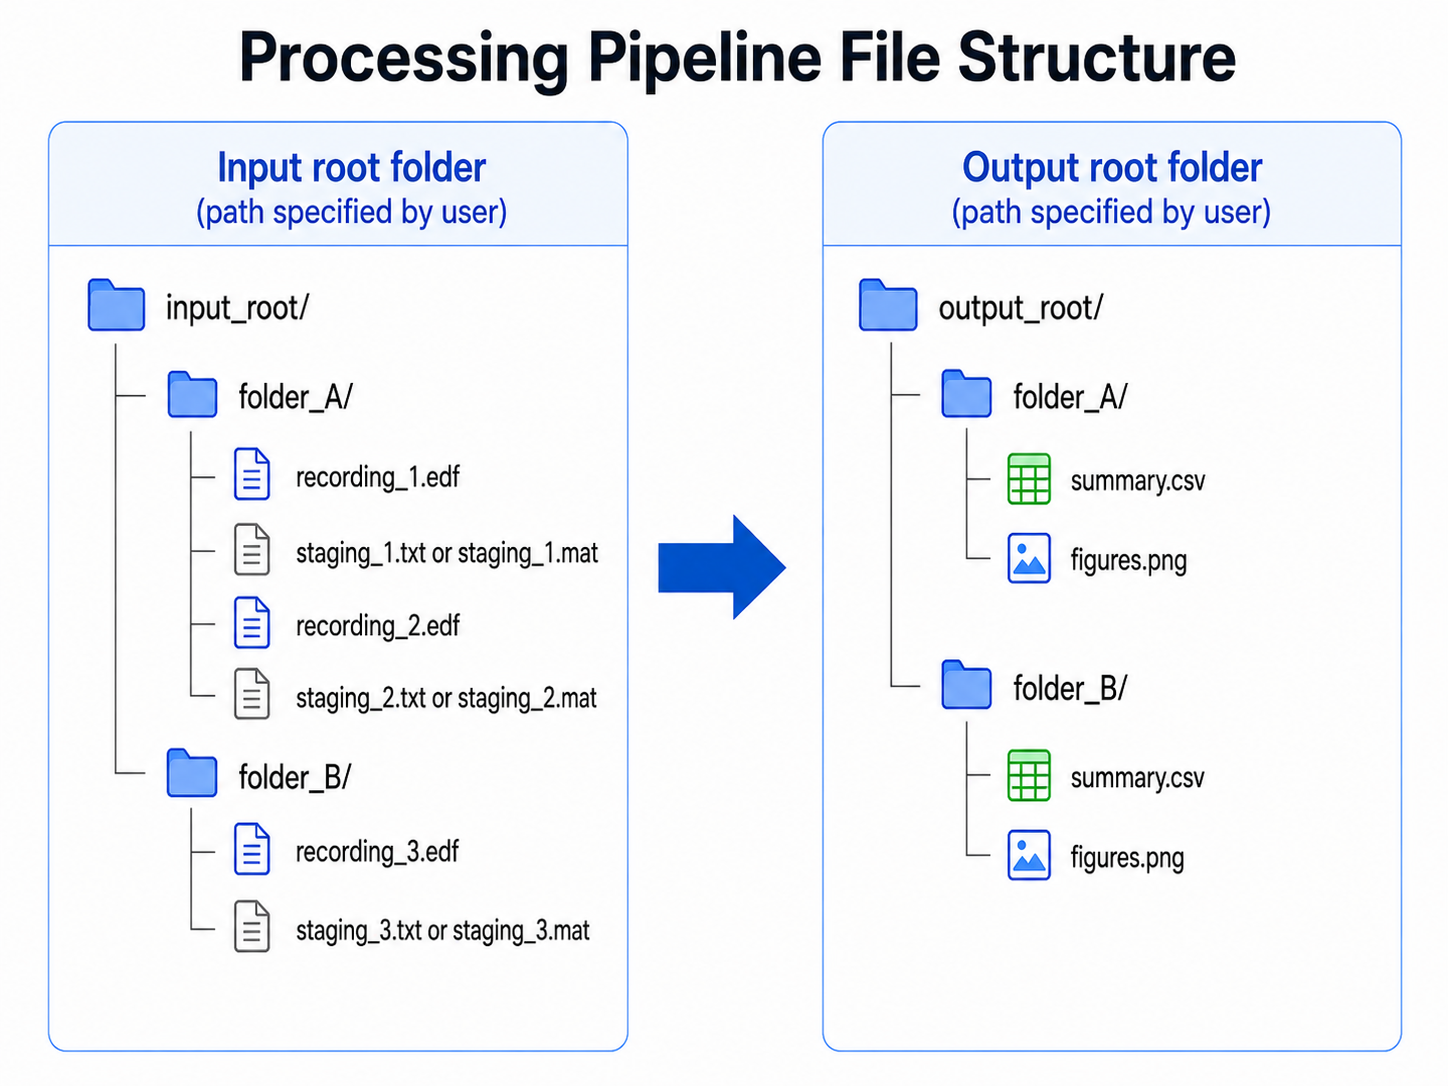

In [2]:
display(Image(filename="file structure.png", width=500))

In [ ]:
###The following are REQUIRED PARAMETERS:

# data_path should point to a folder of folders. Each folder within data_path will have its .edf and .txt / .mat contents analyzed separately
# output_path should point to a folder where you want to store your results. 

# Subfolders within output_path will match the names of the subfolders within data_path
# If matching subfolders have not been created yet, they will be created automatically 
# Each subfolder will store results for the corresponding .edf files in data_path

# Group data into subfolders however you would like. If you want metrics stored per participant, make sure each .edf and .txt / .mat
# file is stored in it's own subfolder in data_path per participant. If you want metrics stored across all participants, just
# create one subfolder within data_path for all .edf and .txt files

# Make sure each .edf filename matches its corresponding .txt / .mat file

data_path = r"Y:\SNL\MBHD\MBHD_test_input"
output_path = r"Y:\SNL\MBHD\MBHD_test_output"

#get the folder paths to pass into the get_sosp_for_folder function
folder_paths = [str(p) for p in Path(data_path).iterdir() if p.is_dir()]


###The following are OPTIONAL PARAMETERS, the default value is what you see, update as necessary:
interest_stage = ['N2', 'SWS'] #use this if sws is a labeled sleep stage you want to analyze: ['N2', 'N3', 'SWS'] #sleep stages interested in evaluating
sp_method = 'Hahn2020' #Method used for spindle detection. See available methods below
so_method = 'Staresina' #Method used for slow oscillation detection. See available methods below
coupling = True #If set to true, additional metrics such as PAC, or spindle to slow oscillation coupling percentage will be calulated and plotted
swa = False #include swa in final csv file
scoring_dur = 30 # (in seconds) the duration of each epoch used for sleep scoring
rerefer = False # If reference channels are not contralateral mostoids or you are unsure, otherwise set to: rereference = ['M1', 'M2'], also optional to set 'average' to use the average of all channels as reference
chan_limit = ['F3', 'C3', 'F4', 'C4', "F7", "Fp1", "Fp2", "P3"] # Use None to process all channels, or use ['Fz', 'Cz', 'F3', 'C3', ...] to process selected channels only.
ch_drop = ['E1', 'E2', 'ChinC', 'ChinL', 'ChinR'] #by default, will drop non-eeg channels. Add any channels that you would want to drop completely
montage_temp = "standard_1005" # Use standard_1005 for mid and high-density caps, standard_1020 for low-density caps, or specify another montage. See other available montages below
is_montage=True # Apply montage or no
baseline = True # Baseline correction before the event detection
verbose = True # Additional diagnostic plotting/ printing if set to true
bad_epoch=True # Whether to mark stage 6 epochs as bad

#The following are customisable Slow Oscillatoin detection metrics, that have different default depending on method used
filter_freq = None
duration = None
filter_type = 'fir'

#The following are customisable Spindle detection metrics, that have different default depending on method used
l_freq = None
h_freq = None
dur_lower = None
dur_upper = None

In [4]:
folder_paths

['Y:\\SNL\\MBHD\\MBHD_test_input\\data']

# Coupling Analysis

In [ ]:
#run coupling analysis
#figs should auto save out
#figs now save, future should stem all info (datetime included) and pass to function calls. Currently overwrites past figs

today_str = datetime.now().strftime("%Y-%m-%d")


#run through all participant folders
for folder in folder_paths:
    folder_path = Path(folder)
    folder_name = folder_path.name
    output_folder = Path(output_path) / folder_name 
    output_folder.mkdir(parents=True, exist_ok=True)

    print(f"RUNNING {folder}")
    
    #try running SOSP
    try:
        start_time = time.time()
        #run analysis function
        event_summary_all, coupling_event_all, so_waveform_all = get_sosp_for_folder(
            folder,
            folder,
            interest_stage=interest_stage,
            sp_method=sp_method,
            so_method=so_method,
            coupling=coupling,
            swa=swa,
            scoring_dur=scoring_dur,
            rerefer=rerefer, 
            chan_limit=chan_limit,
            montage_temp=montage_temp, 
            is_montage=is_montage, 
            filter_freq=filter_freq, 
            duration=duration, 
            filter_type= filter_type, 
            l_freq=l_freq,
            h_freq=h_freq,
            dur_upper=dur_upper,
            dur_lower=dur_lower,
            baseline=baseline,
            verbose=verbose,
            bad_epoch=bad_epoch,
            outpath = output_folder
        )
        
        #save summary for each eeg file within single participant as csv.
        for filename, summary in event_summary_all.items():
            stem = Path(filename).stem  
            csv_path = output_folder / f"{stem}_somnopy_summary_{today_str}.csv"

            summary.to_csv(csv_path, index=False)
            print(f"📄 Saved: {csv_path}")
            
        end_time = time.time()
        duration = end_time - start_time
        print(f"✅ Finished {folder} in {int(duration//60)}m {int(duration%60)}s")

    except Exception as e:
        print(f"❌ Error processing {folder}: {e}")

    #uncomment if you want to try just the first folder
    #break 


    


RUNNING Y:\SNL\MBHD\MBHD_test_input\data
Start event detection for subject MBHD02.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


c:\Users\Beast\Ryan\somnopy\somnopy\somnopy_v2\somnopy\polysomnography.py:262: RuntimeWarning: DigMontage is only a subset of info. There is 1 channel position not present in the DigMontage. The channel missing from the montage is:

['FPz'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if this is not an EEG channel, or use the on_missing parameter if the channel position is allowed to be unknown in your analyses.
  self.raw.set_montage(montage, on_missing='warn')


# YASA: Spectrogram and Sleep Staging on EDF files

The following code cells are examples of using the YasaFunctions class within somnopy. This class provides functions for different types of specific requested analyses such as core body temperature spectrogam overlays and correlations in an easy to use, callable format. 

To start, load in your eeg and hypnogram data from edf and mat/txt files. You also need to define a stage mapping by which your staging codes can be converted to YASA codes. The numbers on the lefthand side of the following stage_mapping variable are the numbers you can edit to correspond to the righthand side YASA codes

In [4]:
#change edf and hypnogram paths you would like to analyze

edf_path = r"Y:\SNL\FEMS\CBT\ryan_cbt_results\follicular_vs_luteal_quadrant_analysis\luteal_data\FEMS_40_S1.edf"
hypnogram_path = r"Y:\SNL\FEMS\CBT\ryan_cbt_results\follicular_vs_luteal_quadrant_analysis\luteal_data\FEMS_40_S1.mat"



#MATLAB TO YASA STAGE CODES
#the strings on the lefthand side are what is present in the txt and mat files
#the numbers on the right correspond to yasa codes
#change the strings on the left to match what is in the mat and txt files
#if they are numbers, remove the quotes. If they are letters, keep the quotes. EX: "W" vs 1


stage_mapping = {
    0: 0, #W
    1: 1, #N1
    2: 2, #N2
    3: 3, #N3
    5: 4, #REM
    6: -1, #ART
    7: -2 #UNS
}


Now, lets instantiate our class with our stage mapping and load our data from the EEG and hypnogram paths. A bunch of variables are returned when loading data if you would like to inspect them, their descriptions are listed below. To view one of these variables, just create a new code cell, type the name of the variable, and click run

In [5]:
#input_data is the EEG data stored as a dict where keys are strings of channel names
#channels is list of channel names
#hypno is the yasa hypnogram object
#recording_start is the recording startime in datetime string format
#sampling_rate is the sampling rate
#hyp_window is the epoch length for each hypnogram
#raw is the raw data

analyzer = YasaFunctions(stage_mapping=stage_mapping)
input_data, channels, hypno, recording_start, sampling_rate, hyp_window, raw = analyzer.load_yasa_from_edf(edf_path, hypnogram_path)

Extracting EDF parameters from Y:\SNL\FEMS\CBT\ryan_cbt_results\follicular_vs_luteal_quadrant_analysis\luteal_data\FEMS_40_S1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 72688999  =      0.000 ... 145377.998 secs...


27-May-26 16:28:26 | WARNING | Hypnogram is LONGER than data by 2.00 seconds. Cropping hypnogram to match data.size.


The following code plots histogram scoring data aligned to the spectrogram of a single specific electrode. You can specify which electrode you would like to use based on the channels listed below, as well as choose what frequency band you would like to visualize with fmin and fmax

In [6]:
channels

['EOG1', 'EOG2', 'F3', 'F4', 'C3', 'C4', 'O1', 'O2', 'CHIN2', 'Fp1', 'Fp2']

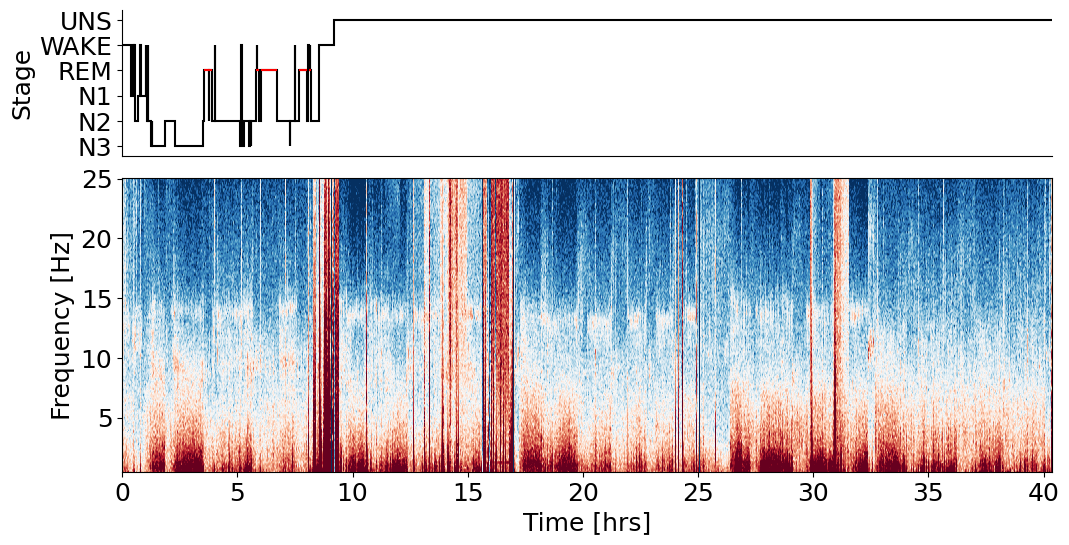

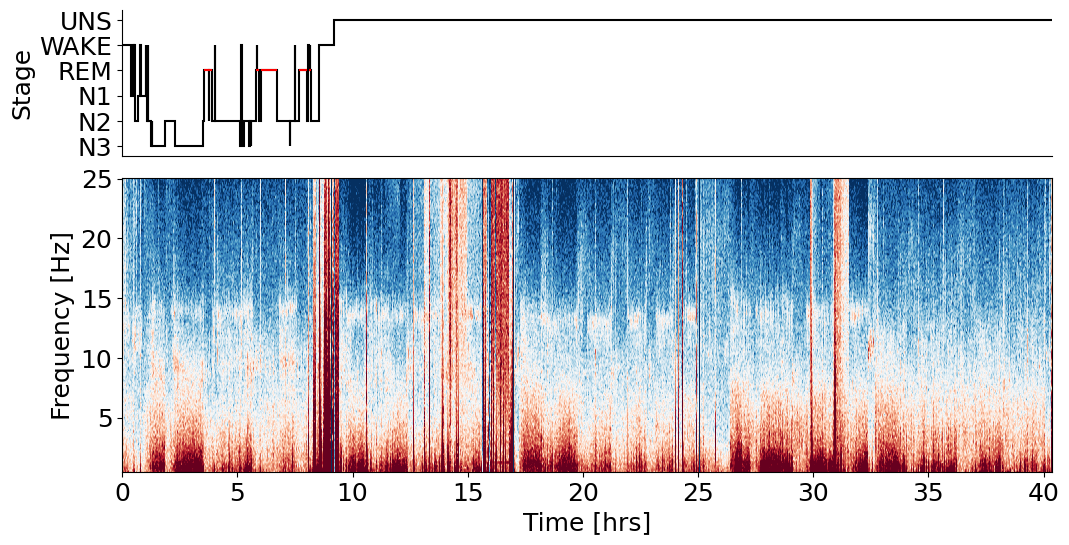

In [7]:
electrode = 'F3' #specify which electrode you want to examine
verbose = True #do you want to see the plot in the notebook or just save it to outpath? Set to True if you want to see it
outpath = None #specify the folder to save to 
filename = Path(edf_path).stem #what do you want to call your output file? 
fmin = 0.5 #OPTIONAL: what's the lowest frequency you would like to include in your spectrogram?
fmax=25 #OPTIONAL: what's the highest frequency you would like to include in your spectrogram?

analyzer.plot_single_electrode(electrode, verbose=verbose, outpath=outpath, filename=filename, fmin=fmin, fmax=fmax)

This next cell plots the same spectrogram / hypnogram combo above but for all electrodes within a recording

In [ ]:
verbose = True #do you want to see the plot in the notebook or just save it to outpath? Set to True if you want to see it
outpath = None #specify the folder to save to 
filename = Path(edf_path).stem #what do you want to call your output file? 
fmin = 0.5 #OPTIONAL: what's the lowest frequency you would like to include in your spectrogram?
fmax=4 #OPTIONAL: what's the highest frequency you would like to include in your spectrogram?

analyzer.plot_all_electrodes(verbose=verbose, outpath=outpath, filename=filename, fmin=fmin, fmax=fmax)

If you would like the spectrogram from an electrode in CSV format, run this next cell. CSV data is stored just like spectrogram data is, with rows corresponding to frequencies, columns corresponding to time, and values corresponding to power. 

In [ ]:
electrode = 'F3' #specify which electrode you want to examine
outpath = None #specify the folder to save to 
filename = Path(edf_path).stem #what do you want to call your output file? 
fmin = 0.5 #OPTIONAL: what's the lowest frequency you would like to include in your spectrogram?
fmax=4 #OPTIONAL: what's the highest frequency you would like to include in your spectrogram?

#uses the same spectrogram calculation methods as yasa
analyzer.save_spectrogram_csv(electrode, outpath=outpath, filename=filename, fmin=fmin, fmax=fmax)


The following code is for core body temperature analyis. First, lets load in our cbt data to our analyzer object

In [9]:
cbt_path = "Y:\SNL\FEMS\CBT\Analysis - Data\Cleaned_Files\Follicular - Copy\FEMS_01_S1.xlsx" #filepath to the cbt data
cbt = analyzer.load_cbt(cbt_path)


<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Beast\AppData\Local\Temp\ipykernel_28476\1884980730.py:1: SyntaxWarning: invalid escape sequence '\S'
  cbt_path = "Y:\SNL\FEMS\CBT\Analysis - Data\Cleaned_Files\Follicular - Copy\FEMS_01_S1.xlsx" #filepath to the cbt data


This cell plots a single electrode spectrogram just as before, but now with a core body temperature reading overlay. 

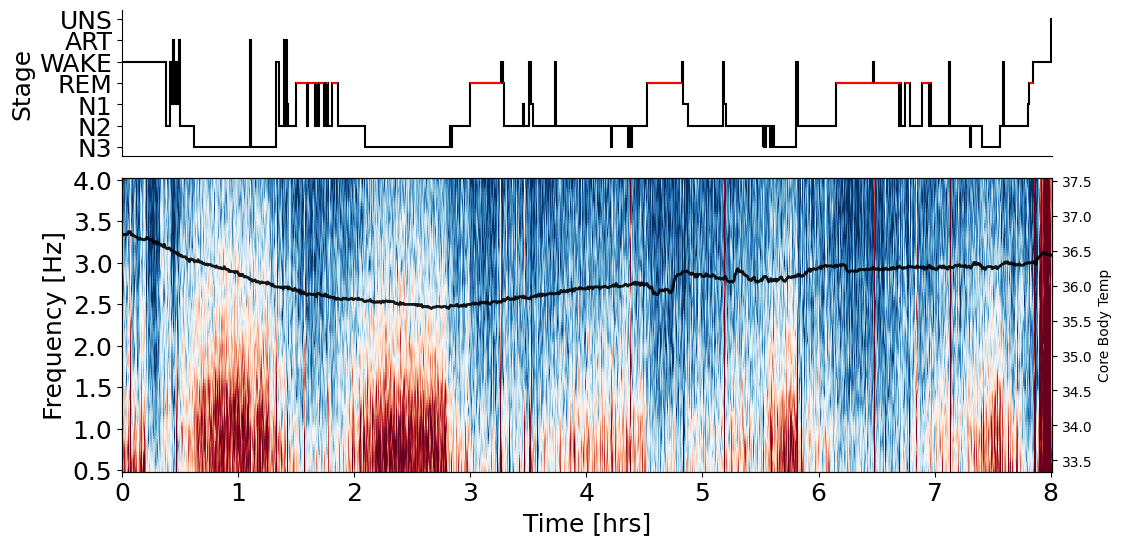

(<Figure size 1200x600 with 3 Axes>,
 <Axes: ylabel='Core Body Temp'>,
       Sample number       date      hour   temp            datetime  \
 0               541 2024-11-05  13:40:53  37.01 2024-11-05 13:40:53   
 1               542 2024-11-05  13:41:23  37.03 2024-11-05 13:41:23   
 2               543 2024-11-05  13:41:53  37.03 2024-11-05 13:41:53   
 3               544 2024-11-05  13:42:23  37.07 2024-11-05 13:42:23   
 4               545 2024-11-05  13:42:53  37.06 2024-11-05 13:42:53   
 ...             ...        ...       ...    ...                 ...   
 2094           2635 2024-11-06  07:07:55  36.45 2024-11-06 07:07:55   
 2095           2636 2024-11-06  07:08:25  36.43 2024-11-06 07:08:25   
 2251           2792 2024-11-06  08:26:25  36.84 2024-11-06 08:26:25   
 2252           2793 2024-11-06  08:26:55  36.84 2024-11-06 08:26:55   
 2253           2794 2024-11-06  08:27:25  36.83 2024-11-06 08:27:25   
 
       hours_from_start  
 0            -9.462222  
 1         

In [ ]:
electrode = 'C3' #specify which electrode you want to examine
verbose = True #do you want to see the plot in the notebook or just save it to outpath? Set to True if you want to see it
outpath = None #specify the folder to save to 
filename = Path(edf_path).stem #what do you want to call your output file? 
fmin = 0.5 #OPTIONAL: what's the lowest frequency you would like to include in your spectrogram?
fmax=4 #OPTIONAL: what's the highest frequency you would like to include in your spectrogram?



analyzer.plot_single_electrode_with_temp(electrode, verbose=verbose, outpath=outpath, filename=filename, fmin=fmin, fmax=fmax)

If you would like to batch process cbt / spectrogram overlays, specify your hypnogram, edf, and cbt folders. Matching file stems will be processed as one.

Found 4 matched .mat/.edf/.xlsx filename sets.

Processing plot for: FEMS_06_S1
Extracting EDF parameters from Y:\SNL\FEMS\PSG\SOSP\processed_eeg_folder\FEMS_06_S1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 16218999  =      0.000 ... 32437.998 secs...


13-May-26 09:33:43 | WARNING | Hypnogram is LONGER than data by 22.00 seconds. Cropping hypnogram to match data.size.


✅ Saved plot for FEMS_06_S1

Processing plot for: FEMS_06_S2
Extracting EDF parameters from Y:\SNL\FEMS\PSG\SOSP\processed_eeg_folder\FEMS_06_S2.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 16070999  =      0.000 ... 32141.998 secs...


13-May-26 09:34:18 | WARNING | Hypnogram is LONGER than data by 18.00 seconds. Cropping hypnogram to match data.size.


KeyboardInterrupt: 

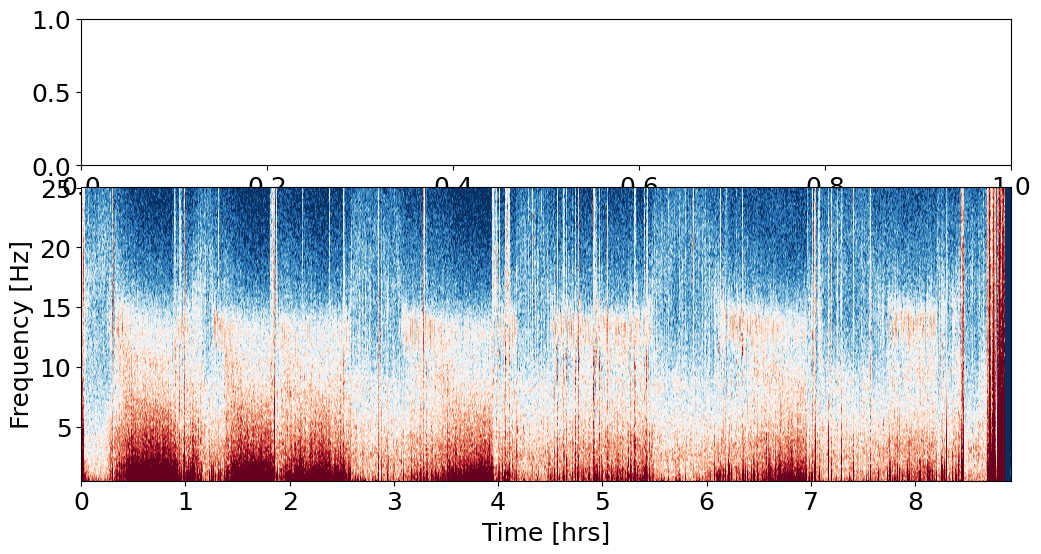

In [ ]:
mat_folder = r"Y:\SNL\FEMS\PSG\PSG Scoring"
edf_folder = r"Y:\SNL\FEMS\PSG\SOSP\processed_eeg_folder"
cbt_folder = r"Y:\SNL\FEMS\CBT\Analysis - Data\Cleaned_Files\error_files"
out_folder = r"c:\Users\Beast\Ryan\somnopy\somnopy\output\test"
electrode="F3"
fmin=0.5
fmax=25


analyzer.batch_plot_spectrograms_with_temp(mat_folder, edf_folder, cbt_folder, out_folder, electrode=electrode, fmin=fmin, fmax=fmax)

Here, instead of generating spectrograms we will perform a batch correlation analysis using spearmans r to correlate cbt with frequency bandpower at each timepoint

In [13]:
mat_folder = r"Y:\SNL\FEMS\PSG\PSG Scoring"
edf_folder = r"Y:\SNL\FEMS\PSG\SOSP\processed_eeg_folder"
cbt_folder = r"Y:\SNL\FEMS\CBT\Analysis - Data\Cleaned_Files\Follicular and Luteal"
out_folder = r"c:\Users\Beast\Ryan\somnopy\somnopy\output\test"
electrode="F3"
fmin=0.5
fmax=4

analyzer.batch_correlate_cbt_with_bandpower(mat_folder, edf_folder, cbt_folder, out_folder, electrode, stage_mapping, band=(fmin, fmax), )

Found 14 matched .mat/.edf/.xlsx filename sets.

Processing correlation for: FEMS_01_S1
Extracting EDF parameters from Y:\SNL\FEMS\PSG\SOSP\processed_eeg_folder\FEMS_01_S1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 14442999  =      0.000 ... 28885.998 secs...


13-May-26 09:36:46 | WARNING | Hypnogram is LONGER than data by 4.00 seconds. Cropping hypnogram to match data.size.


frequency shape: (106,)
times shape: (962,)
power decibel shape: (106, 962)
Number of merged timestamps: 962
✅ Success for FEMS_01_S1: rho=-0.050, p=0.1206, n=962

Processing correlation for: FEMS_01_S2
Extracting EDF parameters from Y:\SNL\FEMS\PSG\SOSP\processed_eeg_folder\FEMS_01_S2.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 15346499  =      0.000 ... 30692.998 secs...


13-May-26 09:36:53 | WARNING | Hypnogram is LONGER than data by 27.00 seconds. Cropping hypnogram to match data.size.


KeyboardInterrupt: 

# Quadrant Analysis

In [2]:
stage_mapping = {
    0: 0, #W
    1: 1, #N1
    2: 2, #N2
    3: 3, #N3
    5: 4, #REM
    6: -1, #ART
    7: -2 #UNS
}

follicular_data = r"Y:\SNL\FEMS\CBT\ryan_cbt_results\follicular_vs_luteal_quadrant_analysis\follicular_data"
luteal_data = r"Y:\SNL\FEMS\CBT\ryan_cbt_results\follicular_vs_luteal_quadrant_analysis\luteal_data"
result_dir = r"Y:\SNL\FEMS\CBT\ryan_cbt_results\follicular_vs_luteal_quadrant_analysis\results"

analyzer = YasaFunctions(stage_mapping=stage_mapping)



In [3]:
analyzer.plot_stage_hours_by_quadrant(
    follicular_folder=follicular_data,
    luteal_folder=luteal_data,
    save_dir=result_dir
)


follicular: found 6 matched file sets.
Processing follicular: FEMS_01_S1
Extracting EDF parameters from Y:\SNL\FEMS\CBT\ryan_cbt_results\follicular_vs_luteal_quadrant_analysis\follicular_data\FEMS_01_S1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 14442999  =      0.000 ... 28885.998 secs...


27-May-26 12:34:08 | WARNING | Hypnogram is LONGER than data by 4.00 seconds. Cropping hypnogram to match data.size.


✅ Success: FEMS_01_S1
Processing follicular: FEMS_05_S1
Extracting EDF parameters from Y:\SNL\FEMS\CBT\ryan_cbt_results\follicular_vs_luteal_quadrant_analysis\follicular_data\FEMS_05_S1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 16577499  =      0.000 ... 33154.998 secs...


27-May-26 12:34:13 | WARNING | Hypnogram is LONGER than data by 25.00 seconds. Cropping hypnogram to match data.size.


✅ Success: FEMS_05_S1
Processing follicular: FEMS_10_S1
Extracting EDF parameters from Y:\SNL\FEMS\CBT\ryan_cbt_results\follicular_vs_luteal_quadrant_analysis\follicular_data\FEMS_10_S1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 16490999  =      0.000 ... 32981.998 secs...


...

27-May-26 12:34:57 | WARNING | Hypnogram is LONGER than data by 27.00 seconds. Cropping hypnogram to match data.size.


✅ Success: FEMS_16_S2
Processing luteal: FEMS_40_S1
Extracting EDF parameters from Y:\SNL\FEMS\CBT\ryan_cbt_results\follicular_vs_luteal_quadrant_analysis\luteal_data\FEMS_40_S1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 72688999  =      0.000 ... 145377.998 secs...


27-May-26 12:35:53 | WARNING | Hypnogram is LONGER than data by 2.00 seconds. Cropping hypnogram to match data.size.


✅ Success: FEMS_40_S1


{'participant_df':           phase participant quadrant  quadrant_num  stage_code stage_name  \
 0    follicular  FEMS_01_S1       q1             1           0       Wake   
 1    follicular  FEMS_01_S1       q1             1           1         N1   
 2    follicular  FEMS_01_S1       q1             1           2         N2   
 3    follicular  FEMS_01_S1       q1             1           3         N3   
 4    follicular  FEMS_01_S1       q1             1           4        REM   
 ..          ...         ...      ...           ...         ...        ...   
 235      luteal  FEMS_40_S1       q4             4           0       Wake   
 236      luteal  FEMS_40_S1       q4             4           1         N1   
 237      luteal  FEMS_40_S1       q4             4           2         N2   
 238      luteal  FEMS_40_S1       q4             4           3         N3   
 239      luteal  FEMS_40_S1       q4             4           4        REM   
 
      n_samples  seconds    minutes     hour

In [2]:
edf_path_2 = r"Y:\SNL\FEMS\PSG\Scored Files\FEMS_01_S2.edf"
hypnogram_path_2 = r"Y:\SNL\FEMS\PSG\Scored Files\FEMS_01_S2.mat"

analyzer_2 = YasaFunctions(stage_mapping=stage_mapping)
input_data_2, channels_2, hypno_2, recording_start_2, sampling_rate_2, hyp_window_2, raw_2 = analyzer_2.load_yasa_from_edf(edf_path_2, hypnogram_path_2)


NameError: name 'stage_mapping' is not defined

In [ ]:
follicular = analyzer.hours_per_stage_per_quadrant()
luteal = analyzer_2.hours_per_stage_per_quadrant()

: 

: 

({'Artifact': <Figure size 800x500 with 1 Axes>,
  'N1': <Figure size 800x500 with 1 Axes>,
  'N2': <Figure size 800x500 with 1 Axes>,
  'N3': <Figure size 800x500 with 1 Axes>,
  'REM': <Figure size 800x500 with 1 Axes>,
  'Unscored': <Figure size 800x500 with 1 Axes>,
  'Wake': <Figure size 800x500 with 1 Axes>},
      recording quadrant     stage stage_name      time
 0   follicular       q1  Artifact   Artifact  0.041667
 1   follicular       q1        N1         N1  0.050000
 2   follicular       q1        N2         N2  0.505972
 3   follicular       q1        N3         N3  0.700000
 4   follicular       q1       REM        REM  0.283333
 5   follicular       q1  Unscored   Unscored  0.000000
 6   follicular       q1      Wake       Wake  0.425000
 7   follicular       q2  Artifact   Artifact  0.000000
 8   follicular       q2        N1         N1  0.025000
 9   follicular       q2        N2         N2  0.922639
 10  follicular       q2        N3         N3  0.741667
 11  follic

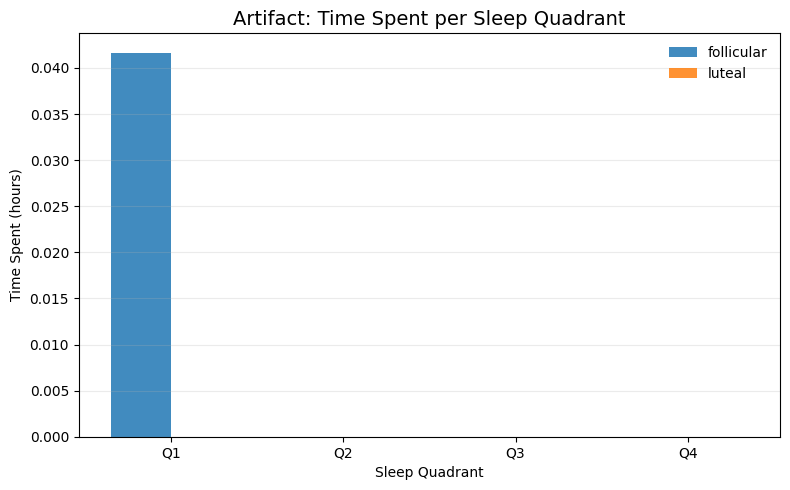

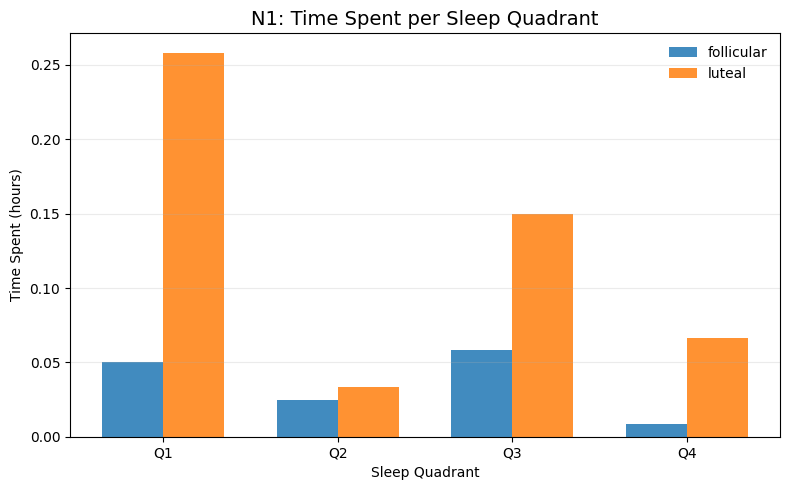

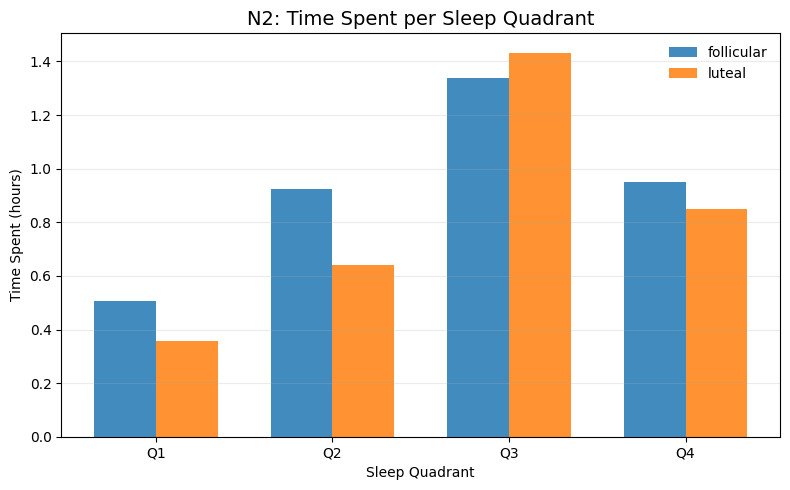

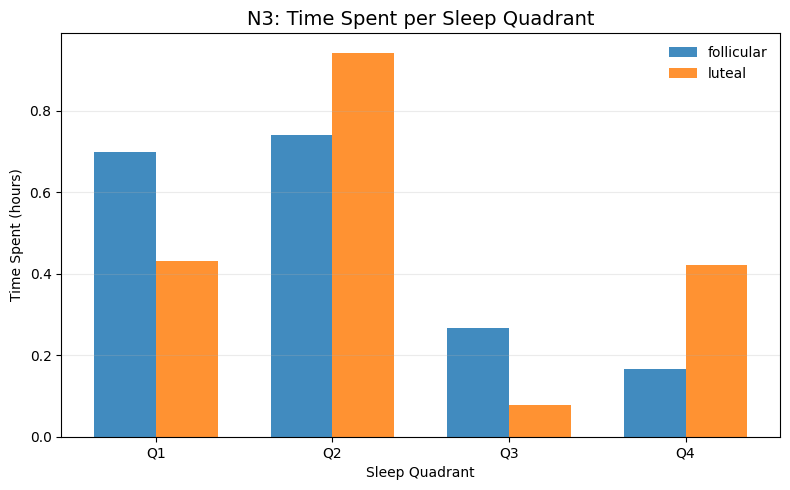

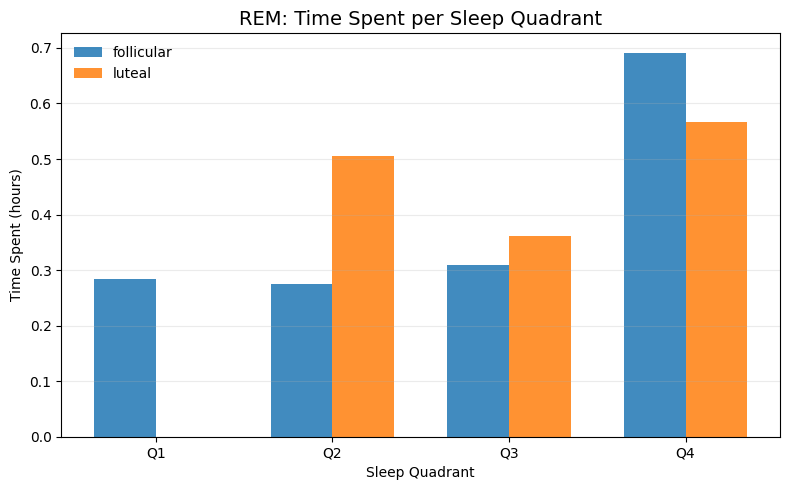

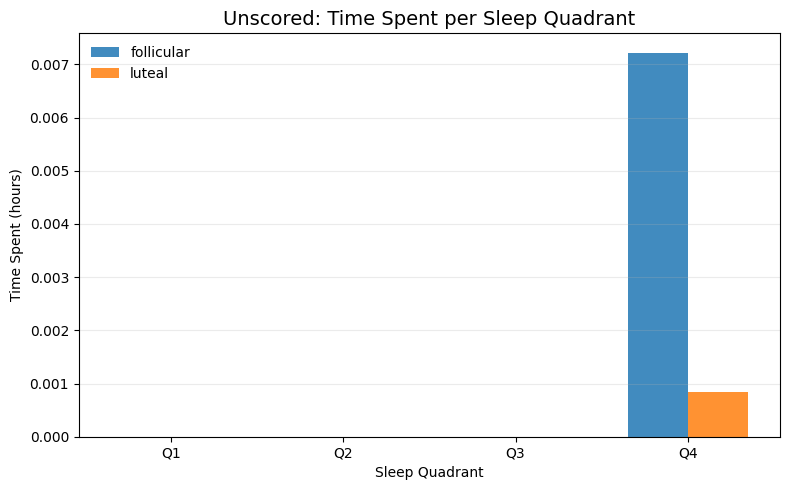

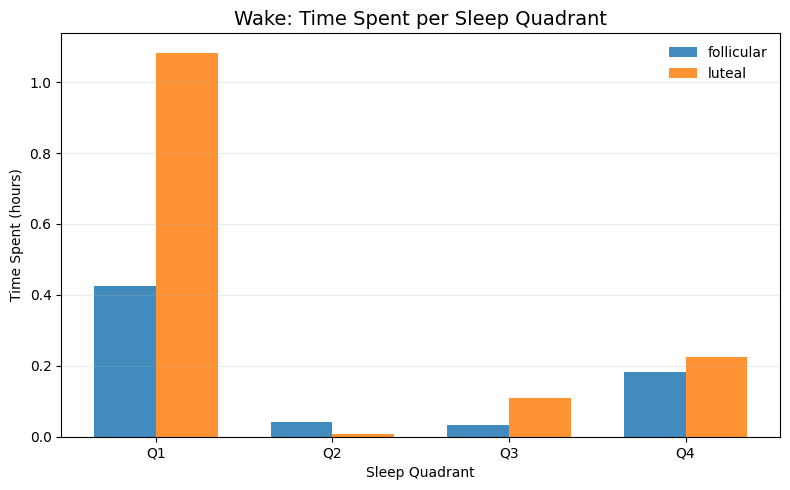

: 

: 

In [ ]:
out_dir = r"C:\Users\Beast\Ryan\somnopy\somnopy\output\test_quads"
rec_names = ['follicular', 'luteal']
analyzer.plot_stage_hours_by_quadrant([follicular, luteal], recording_names=rec_names, save_dir=out_dir)

SID: 1, 5, 10, 13, 16, 40

In [ ]:
hours_per_stage_per_quadrant = analyzer.hours_per_stage_per_quadrant()

: 

: 

In [ ]:
hours_per_stage_per_quadrant

{'q1': {np.int64(-2): np.float64(0.0),
  np.int64(-1): np.float64(0.041666666666666664),
  np.int64(0): np.float64(0.425),
  np.int64(1): np.float64(0.05),
  np.int64(2): np.float64(0.5059722222222223),
  np.int64(3): np.float64(0.7),
  np.int64(4): np.float64(0.2833333333333333)},
 'q2': {np.int64(-2): np.float64(0.0),
  np.int64(-1): np.float64(0.0),
  np.int64(0): np.float64(0.041666666666666664),
  np.int64(1): np.float64(0.025),
  np.int64(2): np.float64(0.9226388888888889),
  np.int64(3): np.float64(0.7416666666666667),
  np.int64(4): np.float64(0.275)},
 'q3': {np.int64(-2): np.float64(0.0),
  np.int64(-1): np.float64(0.0),
  np.int64(0): np.float64(0.03333333333333333),
  np.int64(1): np.float64(0.058333333333333334),
  np.int64(2): np.float64(1.3393055555555555),
  np.int64(3): np.float64(0.26666666666666666),
  np.int64(4): np.float64(0.30833333333333335)},
 'q4': {np.int64(-2): np.float64(0.007222222222222222),
  np.int64(-1): np.float64(0.0),
  np.int64(0): np.float64(0.183

: 

: 

## Automatic Sleep Staging for one EDF (still being worked on)

Extracting EDF parameters from Y:\SNL\MBHD\PSG\edf\MBHD11.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9413499  =      0.000 ... 18826.998 secs...


c:\Users\Beast\anaconda3\envs\somnopy\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


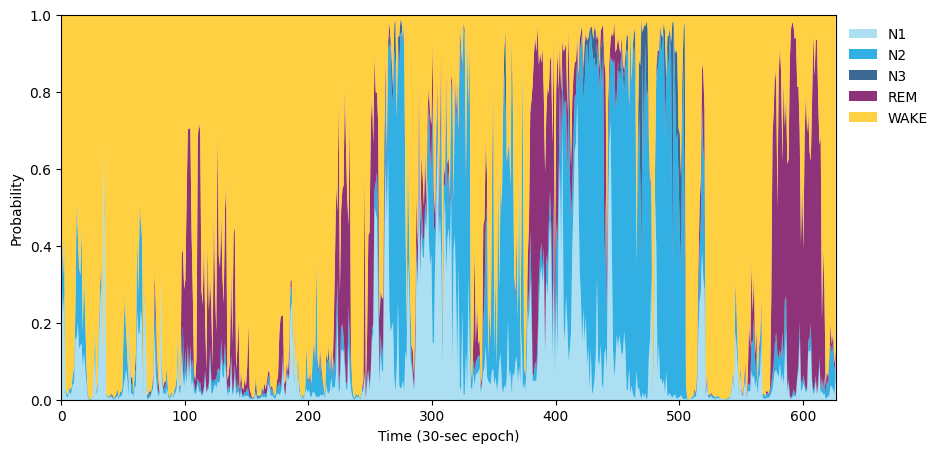

: 

: 

In [ ]:
test_path = r"Y:\SNL\MBHD\PSG\edf\MBHD11.edf" #change path to edf file you want analyzed
outpath = r"C:\Users\Beast\Ryan\somnopy\somnopy\somnopy_v2\output" #change path to output folder to store data

df, hyp, probs, confidence = automatic_sleep_staging(test_path, eeg="C4", eog="EOG1", outpath=outpath)

## Automatic Sleep Staging for a folder of EDFs

In [ ]:
input_path = r"Y:\SNL\MBHD\PSG\edf" #change path to folder of edf files you would like analyzed
outpath = r"C:\Users\Beast\Ryan\somnopy\somnopy\somnopy_v2\output\MBHD_scoring" #change path to output folder to store data

run_sleep_staging_on_folder(input_path, outpath)

: 

: 

In [ ]:
test_path = r"Y:\SNL\MBHD\PSG\edf\MBHD08.edf"
raw = mne.io.read_raw_edf(test_path, preload=True)

Extracting EDF parameters from Y:\SNL\MBHD\PSG\edf\MBHD08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 3824499  =      0.000 ...  7648.998 secs...


: 

: 

In [ ]:
raw.ch_names

['Fp1',
 'Fp2',
 'F3',
 'F4',
 'C3',
 'C4',
 'P3',
 'P4',
 'O1',
 'O2',
 'F7',
 'F8',
 'T7',
 'T8',
 'P7',
 'P8',
 'FPz',
 'Fz',
 'Cz',
 'Pz',
 'POz',
 'Oz',
 'FT9',
 'FT10',
 'M1',
 'M2',
 'EOG1',
 'EOG2',
 'EMG1',
 'EMG2',
 'EMG3',
 'ECG',
 'AF3',
 'AF4',
 'F1',
 'F2',
 'F5',
 'F6',
 'FC1',
 'FC2',
 'FC3',
 'FC4',
 'FC5',
 'FC6',
 'FT7',
 'FT8',
 'C1',
 'C2',
 'C5',
 'C6',
 'CP1',
 'CP2',
 'CP3',
 'CP4',
 'CP5',
 'CP6',
 'TP7',
 'TP8',
 'P1',
 'P2',
 'P5',
 'P6',
 'PO3',
 'PO4',
 'AFp1',
 'AFp2',
 'AF7',
 'AF8',
 'AFF1h',
 'AFF2h',
 'AFF5h',
 'AFF6h',
 'FFC1h',
 'FFC2h',
 'FFC3h',
 'FFC4h',
 'FFC5h',
 'FFC6h',
 'FFT7h',
 'FFT8h',
 'FCC1h',
 'FCC2h',
 'FCC3h',
 'FCC4h',
 'FCC5h',
 'FCC6h',
 'FTT7h',
 'FTT8h',
 'CCP1h',
 'CCP2h',
 'CCP3h',
 'CCP4h',
 'CCP5h',
 'CCP6h',
 'TTP7h',
 'TTP8h',
 'CPP1h',
 'CPP2h',
 'CPP3h',
 'CPP4h',
 'CPP5h',
 'CPP6h',
 'TPP7h',
 'TPP8h',
 'TPP9h',
 'TPP10h',
 'P9',
 'P10',
 'PPO1h',
 'PPO2h',
 'PPO5h',
 'PPO6h',
 'PPO9h',
 'PPO10h',
 'PO7',
 'PO8',
 'PO9',

: 

: 